# Chinese Character Database — Analysis Notebook

**Author:** Robert W Cellucci  
**Project:** CJK (Chinese-Japanese-Korean) SQLite Character Database  

This notebook queries the pre-built `Chinese_Character_Database.db` and is **read-only** with respect to the database. The companion creation notebook builds the database from raw source files.

Every query in this notebook opens a connection wrapped in a `with` block — which manages the transaction (committing or rolling back) rather than closing the connection — enforces foreign key constraints with `PRAGMA foreign_keys = ON`, and reads results directly into a pandas DataFrame. Nothing is written back to disk.

## Analytical Narrative

Mandarin (China / Taiwan), Japanese, and Korean each maintain their own official character standards
for education and literacy. Yet all three draw from the same logographic pool. A
Japanese learner working through the Jōyō list, a Mandarin learner working through
HSK 3.0 or through Taiwan's Ministry of Education standard, and a
Korean learner working through the Korean Educational Hanja list are all engaging with
largely the same script with no published map of where those curricula actually overlap.

This notebook works toward one central finding: **which characters represent a
cross-validated, multi-institutional consensus on foundational Chinese character literacy?**

The sections below build toward that answer incrementally. Sections 1 and 2 characterize
Japan's lists in isolation, first identifying what Japan considers essential that no other
system shares, then tracing how Japan's traditional-form kanji relate to Mainland China's
simplification reforms. Sections 3 and 4 establish pairwise overlaps between Japan and its
East Asian neighbors. Section 5 delivers the core finding: the strict three-way intersection
of Japan, Taiwan, and Korea — **1,579 characters** independently ratified by three national
educational authorities. Section 0 first establishes which of the database's nine
sources qualify as a national standard, since that scoping decision drives every
figure that follows.

## Section Map

| Section | Question | Source Lists Involved |
|---|---|---|
| **0** | Methodology: which lists count as a national standard? | all |
| **1** | Japan Exclusivity: which Japanese characters appear on no other national standard? | `Joyo`, `Jinmeiyo` |
| **2** | How characters from Japan's lists were simplified in China's script reforms | `Joyo`, `trad_simp_map` |
| **3** | Japan <-> Korea pairwise overlap | `Joyo`+`Jinmeiyo`, `KoreanEducationHanja` |
| **4** | Japan <-> Taiwan pairwise overlap | `Joyo`+`Jinmeiyo`, `TaiwanEducationHanzi` |
| **5** | Pan-CJK three-way intersection: core finding | all three standards |
| **6** | Window-function decomposition of the three-way composition | all three standards |

---


## Import Statements

Only three top-level imports are needed:

- `pandas` — in-memory data wrangling and the staging layer for all query results
- `sqlite3` — Python's built-in SQLite driver; no installation required
- `matplotlib` - For some ending visualizations

In [1]:
import pandas as pd          
import sqlite3 as sql         
import matplotlib.pyplot as plt
from contextlib import closing

## Configuration and Connection Helper

`DB_PATH` centralizes the database filename in one place instead of repeating the
literal string in every connection block. `run_query` wraps the connect / PRAGMA /
`read_sql_query` boilerplate that every subsequent cell needs — each call still opens
its own connection (SQLite connections are cheap and this keeps every query's `with`
block scope minimal), but the six lines of setup shrink to a single function call.


In [2]:
DB_PATH = 'Chinese_Character_Database.db'

def run_query(query, params=None):
    """Open a connection to DB_PATH, enforce foreign key constraints, run `query`,
    and return the result as a DataFrame. PRAGMA foreign_keys is reissued on every
    call because SQLite does not persist the setting outside the connection that
    set it."""
    # `with sql.connect(...)` manages the transaction but does NOT close the
    # connection, so closing() is wrapped around it to avoid leaking handles.
    with closing(sql.connect(DB_PATH)) as conn, conn:
        conn.execute("PRAGMA foreign_keys = ON")
        return pd.read_sql_query(query, conn, params=params)


## Database Validation

Before running any analytical queries, it is worth confirming that the database is
structurally sound: all expected tables are present, row counts are plausible, and
foreign key relationships are intact. This section is a sanity check, not part of
the analysis proper but it catches silent corruption or a stale `.db` file early,
before a bad join produces a misleadingly empty result downstream.

In [3]:
# -- Database Validation ------------------------------------------------------
#       Expected tables:
#         - character_table    (spine of the schema; one row per unique codepoint)
#         - character_source   (list membership: Joyo, Jinmeiyo, MoE, HSK, Hanja, etc.)
#         - dic_index_table    (entry numbers in KangXi, Morohashi, Nelson, etc.)
#         - trad_simp_map      (1,210 Traditional -> Simplified codepoint pairs)

master_table = run_query("SELECT type, name, tbl_name FROM sqlite_master ORDER BY type, name")
display(master_table)

# Row counts: a stale or half-built .db shows up here as an implausible count.
row_counts = run_query("""
SELECT 'character_table'  AS table_name, COUNT(*) AS rows FROM character_table
UNION ALL SELECT 'character_source', COUNT(*) FROM character_source
UNION ALL SELECT 'dic_index_table',  COUNT(*) FROM dic_index_table
UNION ALL SELECT 'trad_simp_map',    COUNT(*) FROM trad_simp_map
""")
display(row_counts)

# Referential integrity: PRAGMA foreign_key_check returns one row per violation,
# so an empty frame is the pass condition.
fk_violations = run_query("PRAGMA foreign_key_check")
print(f"Foreign key violations: {len(fk_violations)}")
assert len(fk_violations) == 0, "Referential integrity check failed"


,type,name,tbl_name
0,index,sqlite_autoindex_character_source_1,character_source
1,index,sqlite_autoindex_trad_simp_map_1,trad_simp_map
2,table,character_source,character_source
3,table,character_table,character_table
4,table,dic_index_table,dic_index_table
5,table,trad_simp_map,trad_simp_map


,table_name,rows
0,character_table,9840
1,character_source,28167
2,dic_index_table,9840
3,trad_simp_map,1210


Foreign key violations: 0


---

## Section 0: Methodology - What Counts as a National Standard

Every comparison in this notebook depends on one decision: which rows in
`character_source` represent a *national educational standard*, and which are
something else. The database holds nine sources across four regions, and they are
not equivalent:

| `source` | `source_region` | codepoints | national standard? |
|---|---|---|---|
| `Joyo` | Japan | 2,136 | yes - general-use kanji |
| `Jinmeiyo` | Japan | 863 | yes - name-use kanji |
| `RememberingTheKanji5th` | Japan | 3,030 | **no** - Heisig, a Western textbook |
| `RememberingTheKanji6th` | Japan | 3,000 | **no** - Heisig, a Western textbook |
| `KoreanEducationHanja` | Korea | 1,800 | yes - middle/high school Hanja |
| `KoreanName` | Korea | 6,367 | **no** - name-use inventory, not a curriculum |
| `TaiwanEducationHanzi` | Taiwan | 4,808 | yes - MoE literacy standard |
| `hsk_trad` / `hsk_simp` | China | 3,164 / 2,999 | excluded (see Section 5) |

**This is why every query below filters on `source`, not `source_region`.**
Filtering on `source_region` silently unions Heisig into the Japanese operand and
a 6,367-character name inventory into the Korean one, which inflates every
overlap figure and makes intersections larger than the lists they are supposedly
drawn from. The three standards used throughout are therefore:

- **Japan** = `Joyo` + `Jinmeiyo` = **2,999** codepoints
- **Korea** = `KoreanEducationHanja` = **1,800** codepoints
- **Taiwan** = `TaiwanEducationHanzi` = **4,808** codepoints

An intersection can never exceed the smallest operand, so **1,800 is the hard
ceiling on every figure in this notebook.** Any result above it is a bug, and
that ceiling is the fastest sanity check available on anything reported here.


In [4]:
sources = run_query("""
    SELECT source, source_region, COUNT(DISTINCT codepoint) AS codepoints
    FROM character_source
    GROUP BY source, source_region
    ORDER BY source_region, source
""")
display(sources)

# The three national standards used as operands throughout this notebook.
STANDARDS = "('Joyo', 'Jinmeiyo', 'KoreanEducationHanja', 'TaiwanEducationHanzi')"

# Maps each standard's `source` value onto the region it represents. Used by
# every comparison query below in place of the raw `source_region` column.
STD_REGION = """
    CASE WHEN source IN ('Joyo', 'Jinmeiyo')      THEN 'Japan'
         WHEN source = 'KoreanEducationHanja'      THEN 'Korea'
         WHEN source = 'TaiwanEducationHanzi'      THEN 'Taiwan' END
"""

operands = run_query(f"""
    SELECT {STD_REGION} AS standard, COUNT(DISTINCT codepoint) AS codepoints
    FROM character_source
    WHERE source IN {STANDARDS}
    GROUP BY 1 ORDER BY 1
""")
display(operands)

,source,source_region,codepoints
0,hsk_simp,China,2999
1,hsk_trad,China,3164
2,Jinmeiyo,Japan,863
3,Joyo,Japan,2136
4,RememberingTheKanji5th,Japan,3030
5,RememberingTheKanji6th,Japan,3000
6,KoreanEducationHanja,Korea,1800
7,KoreanName,Korea,6367
8,TaiwanEducationHanzi,Taiwan,4808


,standard,codepoints
0,Japan,2999
1,Korea,1800
2,Taiwan,4808


---

## Section 1: The Japanese Primary Kanji List

Japan maintains two official kanji lists administered by the Ministry of Education:

- **Jōyō kanji** (常用漢字) — 2,136 characters designated for general use in newspapers,
  government documents, and public communication. These are the characters every student
  is expected to master by the end of compulsory education.
- **Jinmeiyō kanji** (人名用漢字) — 863 characters approved for use in personal names
  but not required for general literacy. They extend the usable character set for naming
  purposes beyond the Jōyō core.

Together these two lists define the full scope of officially sanctioned kanji in Japan.
The query below retrieves all 2,999 characters across both lists (the two lists are
disjoint, so 2,136 + 863 sums exactly), which will serve as
the Japan-side operand for all subsequent comparisons.

In [5]:
japanese_characters = run_query("""
SELECT cs.codepoint, MIN(ct.literal) AS literal
FROM character_source AS cs
JOIN character_table AS ct
    ON cs.codepoint = ct.codepoint
WHERE (cs.source = 'Joyo' OR cs.source = 'Jinmeiyo')
GROUP BY cs.codepoint
""")

display(japanese_characters)   # Expected: 2,999 rows


,codepoint,literal
0,19968,一
1,19969,丁
2,19971,七
3,19975,万
4,19976,丈
...,...,...
2994,64101,贈
2995,64103,逸
2996,64104,難
2997,64105,響


### Characters Exclusive to Japan

Of Japan's 2,999 kanji, how many appear on **no other national standard**? The query
below uses a `NOT EXISTS` correlated subquery to filter to codepoints that appear in
`Joyo` or `Jinmeiyo` but in none of Taiwan's MoE list, Korea's Educational Hanja list,
or China's HSK 3.0.

The result is **451 characters**, which includes a large proportion of Jinmeiyo kanji
(name-use characters with limited general circulation) and a smaller number of Joyo
kanji with no clear cognate in other CJK educational frameworks.

*A note on why this is 451 and not 267.* Excluding any codepoint with a source row
outside Japan, rather than one outside the other three **standards**, gives 267 - but
that version also excludes anything appearing in `KoreanName`, and `KoreanName` is a
name inventory rather than a curriculum. That difference is not academic: it drops
the canonical kokuji 峠 (*toge*), which appears in `KoreanName` despite being a
character invented in Japan. 451 is the figure that answers the question as asked.


In [6]:
japan_exclusive = run_query(f"""
    SELECT
        cs.codepoint,
        ct.literal
    FROM character_source AS cs
    JOIN character_table AS ct
        ON cs.codepoint = ct.codepoint
    WHERE cs.source IN ('Joyo', 'Jinmeiyo')
    AND NOT EXISTS (
          -- Exclude codepoints appearing on any other NATIONAL STANDARD.
          -- Heisig and KoreanName are deliberately not disqualifying here.
          SELECT 1
          FROM character_source AS cs2
          WHERE cs2.codepoint = cs.codepoint
            AND cs2.source IN ('TaiwanEducationHanzi', 'KoreanEducationHanja',
                               'hsk_trad', 'hsk_simp')
      )
    GROUP BY cs.codepoint, ct.literal
    ORDER BY cs.codepoint
""")

display(japan_exclusive)   # Expected: 451 rows

,codepoint,literal
0,20001,両
1,20028,丼
2,20055,乗
3,20096,亀
4,20120,亘
...,...,...
446,64101,贈
447,64103,逸
448,64104,難
449,64105,響


### A Note About Kokuji

**Kokuji** (国字, literally "country characters") are kanji invented in Japan. These
characters have no Chinese etymological origin and exist only in the Japanese writing
system. Well-known examples include 働 (*hataraku*, to work) and 峠 (*toge*, mountain pass).

Because kokuji were never part of the Chinese character pool, they are by definition
absent from Taiwan's MoE list, Korea's Hanja list, and China's HSK, which makes them a
structural subset of the Japan-exclusive set identified above.

This database cannot identify kokuji directly - doing so requires etymological data
that Unihan's IRG source fields only approximate. So the 451-character set is best read
as *characters absent from the other national curricula*, of which true kokuji are a
small minority. Sizing that minority properly would mean joining against `kIRG_GSource`
and `kIRG_TSource` from the Unihan Variants and IRGSources files, which is a natural
extension rather than a finding this notebook makes.


## Section 2: How Japan's Kanji Were Simplified in Mainland China

Japan and Mainland China both reformed their official character sets in the twentieth
century, independently simplifying stroke structures that had remained stable for
centuries. The reforms took different forms including Japan's Jōyō revisions (1946, 1981, 2010)
produced *shinjitai* (新字体) variants; China's reforms (1956, 1964) produced *simplified
characters* (简体字) and the two systems did not coordinate. The result is a complex
mapping where some Japanese and Chinese forms converge on the same simplified shape,
others diverge, and some characters were simplified in only one system.

The `trad_simp_map` table records **1,210** explicit Traditional-to-Simplified codepoint
pairs, derived from the HSK 3.0 dataset. (Earlier drafts of this notebook cited 3,165
here; that figure is the row count of the HSK traditional-form source, not the number
of mapping pairs the transform actually produces.) The query below joins Japan's Jōyō list
against this map to surface the **463 Jōyō kanji** that have a recorded Mainland
Chinese simplified counterpart displaying both the traditional form (as used in
Japan) and the simplified form (as used in the PRC) side by side.

Note that this query is scoped to Jōyō only (not Jinmeiyō), since Jinmeiyō characters
are unlikely to appear in HSK-derived simplification data.

In [7]:
j_simp = run_query("""
SELECT 
    map.trad_codepoint,   -- Codepoint of the traditional form (as used in Japan)
    map.trad_literal,     -- Traditional character glyph
    map.simp_codepoint,   -- Codepoint of the Mainland Chinese simplified form
    map.simp_literal      -- Simplified character glyph
FROM character_source AS cs
    JOIN trad_simp_map AS map 
    ON cs.codepoint = map.trad_codepoint   -- Match Joyo codepoints to their traditional-form entry in the map
WHERE cs.source = 'Joyo'                   -- Scoped to Joyo only; Jinmeiyo excluded
ORDER BY cs.codepoint
""")

display(j_simp)   # Expected: 463 rows


,trad_codepoint,trad_literal,simp_codepoint,simp_literal
0,20006,並,24182,并
1,20094,乾,24178,干
2,20341,併,24182,并
3,20406,侶,20387,侣
4,20418,係,31995,系
...,...,...,...,...
458,39854,鮮,40092,鲜
459,40165,鳥,40479,鸟
460,40180,鳴,40483,鸣
461,40372,鶴,40548,鹤


## Section 3: Japan <-> Korea Pairwise Overlap

Korea's Educational Hanja list (한문 교육용 기초 한자) designates 1,800 characters for
instruction in middle and high school. Like Japan's kanji system, Korean Hanja are
traditional-form characters drawn from the script pool that predates both Japan's
shinjitai reforms and China's simplification program. That shared traditional-form
heritage makes Japan-Korea comparisons methodologically cleaner than any comparison
involving China's simplified forms.

The query identifies codepoints appearing in a Japanese standard (`Joyo` or
`Jinmeiyo`) **and** in `KoreanEducationHanja`. Note the filter is on `source`, not
`source_region` - see Section 0. The `source_count` column reports how many
*individual lists* a character belongs to, so it exceeds 2 for characters present in
both Joyo and Jinmeiyo.

Result: **1,615 characters**, or 89.7% of Korea's entire 1,800-character list. Nearly
everything Korea teaches, Japan also teaches.


In [8]:
j_k_full = run_query(f"""
    SELECT
        cs.codepoint,
        ct.literal,
        COUNT(DISTINCT cs.source) AS source_count   -- individual lists, not regions
    FROM character_source AS cs
    JOIN character_table AS ct
        ON cs.codepoint = ct.codepoint
    WHERE cs.source IN ('Joyo', 'Jinmeiyo', 'KoreanEducationHanja')
    GROUP BY cs.codepoint, ct.literal
    HAVING COUNT(DISTINCT {STD_REGION}) = 2        -- strict: both standards present
    ORDER BY cs.codepoint
""")

display(j_k_full)   # Expected: 1,615 rows

,codepoint,literal,source_count
0,19968,一,2
1,19969,丁,2
2,19971,七,2
3,19976,丈,2
4,19977,三,2
...,...,...,...
1610,40664,默,2
1611,40723,鼓,2
1612,40763,鼻,2
1613,40778,齊,2


## Section 4: Japan <-> Taiwan Pairwise Overlap

Taiwan's Ministry of Education list (國語常用字表) designates 4,808 characters for
standard Mandarin literacy instruction. Like Korea's Hanja list it operates entirely in
traditional forms - the script Japan also used prior to its shinjitai substitutions.
Taiwan's list is by far the largest of the three, which makes it a generous comparator:
almost any character Japan teaches has a reasonable chance of appearing somewhere in
Taiwan's broader inventory.

Result: **2,395 characters**, the largest pairwise overlap in the dataset - which is the
direction list size alone would predict, since Taiwan's list is 2.7x the size of Korea's.

*This reverses an earlier version of this notebook,* which reported Japan-Korea as the
larger pair (2,904 vs. 2,599) and explained the inversion as a consequence of Japan's
shinjitai reforms diverging from the traditional forms Taiwan retains. That explanation
was reasoning about an artifact: the earlier Korean operand unioned in a 6,367-character
name inventory. With the standards correctly scoped, no inversion exists and no
explanation is required. Shinjitai divergence is still real and still suppresses
Japan-Taiwan overlap below what Taiwan's list size alone would suggest - 2,395 of
Japan's 2,999 is 79.9%, not the near-total coverage a 4,808-character superset might
imply - but it does not reorder the pairs.


In [9]:
j_t_full = run_query(f"""
    SELECT
        cs.codepoint,
        ct.literal,
        COUNT(DISTINCT cs.source) AS source_count
    FROM character_source AS cs
    JOIN character_table AS ct
        ON cs.codepoint = ct.codepoint
    WHERE cs.source IN ('Joyo', 'Jinmeiyo', 'TaiwanEducationHanzi')
    GROUP BY cs.codepoint, ct.literal
    HAVING COUNT(DISTINCT {STD_REGION}) = 2
    ORDER BY cs.codepoint
""")

display(j_t_full)   # Expected: 2,395 rows

,codepoint,literal,source_count
0,19968,一,2
1,19969,丁,2
2,19971,七,2
3,19976,丈,2
4,19977,三,2
...,...,...,...
2390,40718,鼎,2
2391,40723,鼓,2
2392,40763,鼻,2
2393,40778,齊,2


## Section 5: Core Finding - The Pan-CJK Three-Way Intersection

The query below is the analytical destination of the notebook. It asks one question:
**which characters appear simultaneously on Japan's Joyo/Jinmeiyo lists, Taiwan's
Ministry of Education standard, and Korea's Educational Hanja list?**

The answer is **1,579 characters** - a set independently ratified by three national
educational authorities, across three languages, over decades of curriculum revision.
No single institution designed this overlap; it emerged from convergent pedagogical
judgment about what logographic literacy requires.

The number sits just under Korea's 1,800-character ceiling, and that proximity is the
finding. **87.7% of Korea's entire Educational Hanja list falls inside the three-way
core.** The consensus set is, to a first approximation, Korea's list - the smallest and
most selective of the three - with 221 characters removed. Japan and Taiwan both teach
nearly everything Korea does, plus substantially more that they do not share.

**Why these three lists, and not China (HSK)?**
HSK 3.0 is represented in this database in its traditional character forms (`hsk_trad`),
not the simplified forms actually used in PRC classrooms. Including it would compare
traditional-form proxies against the genuine traditional-script standards of Japan,
Taiwan, and Korea - a methodologically unsound equivalence. China's data is used in
Section 2, where the comparison is directionally informative, but it is excluded from
the core intersection for this reason.

`HAVING COUNT(DISTINCT ...) = 3` is what enforces the strict intersection: every
returned row must have all three standards present before it can appear at all. A
`source_count` column would only restate the filter that already produced the rows, so
it is omitted here.


In [10]:
j_t_k_full = run_query(f"""
    SELECT
        cs.codepoint,
        ct.literal
    FROM character_source AS cs
    JOIN character_table AS ct
        ON cs.codepoint = ct.codepoint
    WHERE cs.source IN {STANDARDS}
    GROUP BY cs.codepoint, ct.literal
    HAVING COUNT(DISTINCT {STD_REGION}) = 3
    ORDER BY cs.codepoint
""")

display(j_t_k_full)   # Expected: 1,579 rows

# Ceiling check: the intersection cannot exceed the smallest operand (Korea, 1,800).
assert len(j_t_k_full) <= 1800, "Intersection exceeds its smallest operand - scoping bug"
print(f"{len(j_t_k_full)} of Korea's 1,800 characters "
      f"({100 * len(j_t_k_full) / 1800:.1f}%) are shared by all three standards.")

,codepoint,literal
0,19968,一
1,19969,丁
2,19971,七
3,19976,丈
4,19977,三
...,...,...
1574,40664,默
1575,40723,鼓
1576,40763,鼻
1577,40778,齊


1579 of Korea's 1,800 characters (87.7%) are shared by all three standards.


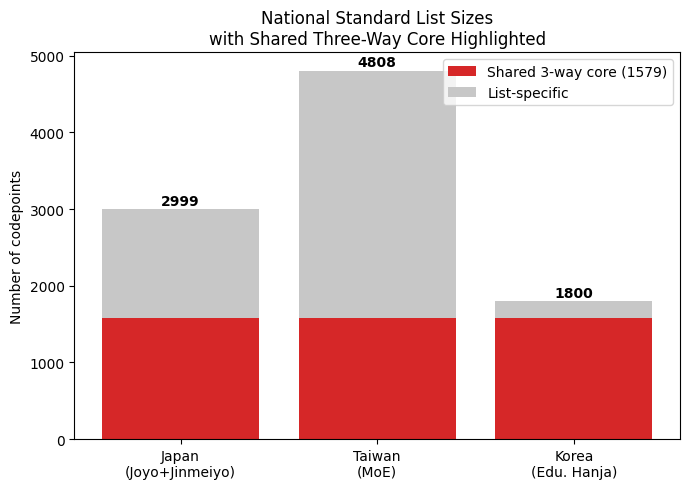

In [11]:
# The earlier source inventory now lives in Section 0. This cell charts the result.
totals = {'Japan\n(Joyo+Jinmeiyo)': 2999, 'Taiwan\n(MoE)': 4808, 'Korea\n(Edu. Hanja)': 1800}
three_way_core = len(j_t_k_full)

countries = list(totals)
total_vals = list(totals.values())
core_vals = [three_way_core] * len(countries)
remainder_vals = [t - c for t, c in zip(total_vals, core_vals)]
assert all(r >= 0 for r in remainder_vals), "Core exceeds a list total - scoping bug"

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(countries, core_vals, label=f'Shared 3-way core ({three_way_core})', color='#d62728')
ax.bar(countries, remainder_vals, bottom=core_vals, label='List-specific', color='#c7c7c7')

for i, t in enumerate(total_vals):
    ax.text(i, t + 60, str(t), ha='center', fontweight='bold')

ax.set_ylabel('Number of codepoints')
ax.set_title('National Standard List Sizes\nwith Shared Three-Way Core Highlighted')
ax.legend()
plt.tight_layout()
plt.show()

## Section 6: Window-Function View of the Three-Way Composition

The queries above establish overlap one relationship at a time. The query below computes
the full decomposition in a single pass - for each standard, how many of its characters
are exclusive, shared with exactly one other, or shared with both.

Two things worth understanding well enough to explain in an interview:

**The first window function counts standards per character and carries that value onto
every row for that character.** `COUNT(*) OVER (PARTITION BY codepoint)` in the `tiered`
CTE does not collapse rows the way a `GROUP BY` would. For each codepoint it counts how
many standard-rows exist and attaches that same count to *every* row belonging to that
codepoint. A character present in Japan, Taiwan, and Korea gets `n_standards = 3` on all
three of its rows; a character present in Japan alone gets `1` on its single row. That is
what lets the outer `GROUP BY standard, n_standards` bucket every character into an
exclusive / shared-by-two / shared-by-three tier per standard.

**The second nests an aggregate inside a window function** -
`SUM(COUNT(*)) OVER (PARTITION BY standard)` - to get each tier's share of its own
standard's list. `COUNT(*)` first collapses each `(standard, n_standards)` group down to
a row count; the outer `SUM(...) OVER (...)` then re-expands it, summing across all three
tiers within a standard to recover that standard's grand total, without a second query or
a self-join. Dividing the group's count by that windowed sum gives the percentage.

The `DISTINCT` in `standard_membership` matters: a character in both Joyo and Jinmeiyo has
two Japanese source rows, and without deduplication it would count as two standards and
land in the wrong tier.

The decomposition is where the three lists stop looking alike. Korea's list is almost
entirely inside the core (87.7%), with only 19 characters exclusive to it. Taiwan's is the
opposite - 46.7% of its 4,808 characters appear on neither of the others, the largest
exclusive share of the three. So the three-way core is not one oversized list absorbing
two smaller ones; it is close to the whole of the smallest list, carved out of two
substantially larger and more divergent inventories.

Korea's 19 exclusive characters are themselves informative: 敎, 淸, 靑, 硏, 擧 and the
rest are older glyph forms that Korean retains while Japan and Taiwan use variants at
*different codepoints*. They are not different characters so much as different encodings
of the same character - the mirror image of the Han unification limitation noted below,
where distinct characters collapse onto one codepoint.


In [12]:
tiered_query = f"""
WITH standard_membership AS (
    -- DISTINCT collapses Joyo+Jinmeiyo into a single 'Japan' membership row
    SELECT DISTINCT codepoint, {STD_REGION} AS standard
    FROM character_source
    WHERE source IN {STANDARDS}
),
tiered AS (
    SELECT
        codepoint,
        standard,
        COUNT(*) OVER (PARTITION BY codepoint) AS n_standards
    FROM standard_membership
)
SELECT
    standard,
    n_standards,
    COUNT(*) AS chars,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (PARTITION BY standard), 1) AS pct_of_standard
FROM tiered
GROUP BY standard, n_standards
ORDER BY standard, n_standards
"""

tiered_result = run_query(tiered_query)
display(tiered_result)

# Reshape into the exclusive / shared_by_two / shared_by_three columns the chart expects
tier_labels = {1: 'exclusive', 2: 'shared_by_two', 3: 'shared_by_three'}
tiered_result['tier'] = tiered_result['n_standards'].map(tier_labels)

decomp = (
    tiered_result
    .pivot(index='standard', columns='tier', values='chars')
    .fillna(0)
    .astype(int)
    [['exclusive', 'shared_by_two', 'shared_by_three']]
)
display(decomp)

# Each row must sum to that standard's published list size.
expected = {'Japan': 2999, 'Korea': 1800, 'Taiwan': 4808}
for region, total in expected.items():
    assert decomp.loc[region].sum() == total, f"{region} tiers sum to {decomp.loc[region].sum()}, expected {total}"
print("Tier totals reconcile to published list sizes.")

,standard,n_standards,chars,pct_of_standard
0,Japan,1,568,18.9
1,Japan,2,852,28.4
2,Japan,3,1579,52.7
3,Korea,1,19,1.1
4,Korea,2,202,11.2
5,Korea,3,1579,87.7
6,Taiwan,1,2247,46.7
7,Taiwan,2,982,20.4
8,Taiwan,3,1579,32.8


tier,exclusive,shared_by_two,shared_by_three
standard,,,
Japan,568,852,1579
Korea,19,202,1579
Taiwan,2247,982,1579


Tier totals reconcile to published list sizes.


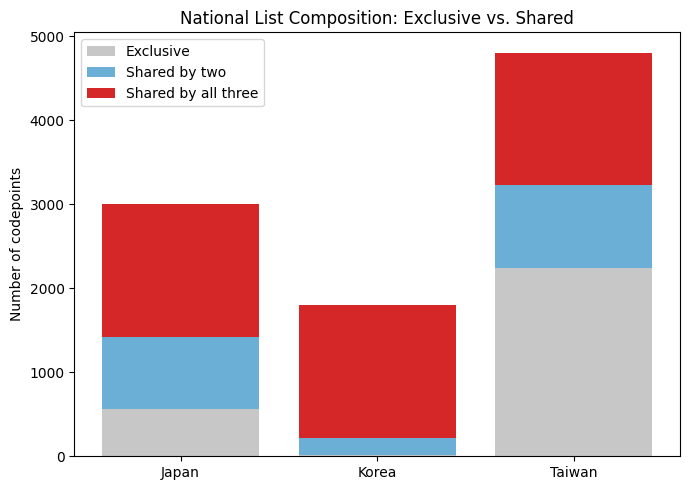

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))
bottom = [0, 0, 0]
colors = {'exclusive': '#c7c7c7', 'shared_by_two': '#6baed6', 'shared_by_three': '#d62728'}
labels = {'exclusive': 'Exclusive', 'shared_by_two': 'Shared by two', 'shared_by_three': 'Shared by all three'}

for col in ['exclusive', 'shared_by_two', 'shared_by_three']:
    ax.bar(decomp.index, decomp[col], bottom=bottom, label=labels[col], color=colors[col])
    bottom = [b + v for b, v in zip(bottom, decomp[col])]

ax.set_ylabel('Number of codepoints')
ax.set_title('National List Composition: Exclusive vs. Shared')
ax.legend()
plt.tight_layout()
plt.show()

# Conclusion

This notebook set out to answer one question: which characters represent a genuine,
independently-arrived-at consensus across the three living traditional-character
educational systems? The answer is the **1,579-character** intersection of Japan's
Joyo/Jinmeiyo lists, Taiwan's Ministry of Education standard, and Korea's Educational
Hanja list - a set no single authority designed, but one all three converged on through
separate curriculum decisions.

The window-function decomposition qualifies that headline number in the direction that
makes it interesting. The core is not evenly drawn from the three lists. It accounts for
**87.7% of Korea's** 1,800-character list, **52.7% of Japan's** 2,999, and only **32.8%
of Taiwan's** 4,808. Korea's Educational Hanja list is, in effect, almost a subset of what
Japan and Taiwan both already teach - only 19 of its characters appear on neither - while
Taiwan's much larger inventory is 46.7% exclusive. The consensus is therefore close to
the whole of the smallest list rather than a narrow band carved out of three comparable
ones, and the pairwise figures (Japan∩Taiwan = 2,395; Korea∩Taiwan = 1,745; Japan∩Korea =
1,615) shrink only modestly once all three must agree.

**A note on an earlier version of this analysis.** Prior drafts reported the core at 2,573
characters and the Japan-Korea pair at 2,904. Those figures came from filtering on
`source_region` rather than `source`, which unioned Heisig's *Remembering the Kanji* into
the Japanese operand and a 6,367-character name inventory into the Korean one. The result
was an intersection larger than the 1,800-character list it was supposedly drawn from -
arithmetically impossible, and the tell that the scoping was wrong. Section 0 documents
the corrected operand definitions, and the ceiling assertion in Section 5 now fails loudly
if the bug is ever reintroduced.

China's HSK data is intentionally left out of the core intersection. As discussed in
Section 5, `hsk_trad` reflects traditional-form proxies rather than the simplified
characters actually taught in PRC classrooms, so folding it into a strict comparison
against genuinely traditional-script standards would be methodologically unsound. Where
China's data does appear - the Joyo-to-simplified mapping in Section 2 - it is used
descriptively, not as a fourth operand.


### Known Limitations

**Han Unification overcounts true overlap.** Unicode merged visually similar CJK
characters into single codepoints. Characters that are functionally distinct across
regions but share a codepoint due to glyph unification are counted as one, inflating
apparent overlap. Regional glyph variation is not captured by Unihan alone.

**Codepoint divergence undercounts it in the other direction.** Korea's 19 exclusive
characters (敎, 淸, 靑, 硏 and others) are older glyph forms of characters Japan and Taiwan
also teach, encoded at different codepoints. A codepoint-anchored comparison treats those
as non-matches. Both effects are present; they do not cancel, and neither is quantified
here.

**HSK is represented in traditional forms only.** The `hsk_trad` source contains
traditional written forms of HSK 3.0 vocabulary, not the simplified forms used in PRC
classrooms. Cross-script comparisons involving China reflect traditional character
inventories, which are no longer the characters Mainland learners actually study.

**Non-standard sources are present in the database but excluded from all comparisons.**
Heisig's *Remembering the Kanji* (5th and 6th editions) and the Korean name inventory are
retained for extensibility, not analysis. Any query filtering on `source_region` rather
than `source` will silently include them; see Section 0.
